# RAF-DB Facial Emotion Recognition — DDAMFN Fine-Tuning

Fine-tunes **DDAMFN** (Dual-Direction Attention Mixed Feature Network) on the **RAF-DB** basic
7-emotion dataset, starting from an **MS-Celeb-1M-pretrained** face backbone.

**Why DDAMFN:** a purpose-built facial-expression model that reaches ~91–92% on RAF-DB, well above
generic ImageNet backbones on faces.

**Target:** ~90–92% overall accuracy on the official 3,068-image test set.

### Methodology
- Validation is carved from the **training** set; the 3,068 test images are evaluated **once**, at the end.
- Reports **overall** and **mean-class (balanced)** accuracy (RAF-DB is imbalanced — Fear/Disgust are small).
- A single fixed 3-/5-scale sentiment mapping.

### Before you run
1. Add the **`raf-db-emotion-classification-challenge`** dataset to this notebook.
2. **Settings → Accelerator → GPU** (T4 or P100).
3. **Settings → Internet → ON** (needed to clone the DDAMFN repo).
4. Run all cells top to bottom.

## 1 · Environment, repo & configuration

In [1]:
import os, sys, random, json, numpy as np, torch

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ---------------- Hyper-parameters (edit here) ----------------
CFG = dict(
    img_size    = 112,    # DDAMFN backbone is 112x112 (NOT 224)
    batch_size  = 128,
    epochs      = 40,     # repo default is 60; 40 is plenty and safe within Kaggle limits
    lr          = 5e-4,
    val_split   = 0.10,   # validation fraction carved out of TRAIN
    num_head    = 2,
    num_workers = 2,      # set 0 if the DataLoader hangs on Kaggle
)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---------------- Clone DDAMFN ----------------
REPO = '/kaggle/working/DDAMFN'
if not os.path.exists(REPO):
    os.system(f'git clone --depth 1 https://github.com/SainingZhang/DDAMFN {REPO}')
os.chdir(REPO)                                       # so the model's relative './pretrained/...' path resolves
sys.path.insert(0, REPO)                             # for: from networks.DDAM import DDAMNet
sys.path.insert(0, os.path.join(REPO, 'DDAMFN++'))  # for: from sam import SAM

# torch>=2.6 defaults torch.load(weights_only=True), which cannot unpickle the repo's MFN backbone
# (it is a full nn.Module, not a state_dict). Force False — it is the repo's own trusted file.
# Reference the PRISTINE original loader (torch.serialization.load is never reassigned),
# so re-running this cell can never make the patch wrap itself -> no RecursionError.
from torch.serialization import load as _torch_load_orig
def _safe_load(*a, **k):
    k.setdefault('weights_only', False)
    return _torch_load_orig(*a, **k)
torch.load = _safe_load

# sanity-check the pretrained backbone actually downloaded (not a tiny git-LFS pointer)
mfn = os.path.join(REPO, 'pretrained', 'MFN_msceleb.pth')
sz = os.path.getsize(mfn) if os.path.exists(mfn) else 0
print(f'torch {torch.__version__} | device {DEVICE} | MFN backbone {sz:,} bytes')
assert sz > 1_000_000, 'Backbone looks like an LFS pointer -> run:  !cd /kaggle/working/DDAMFN && git lfs pull' 

Cloning into '/kaggle/working/DDAMFN'...


torch 2.10.0+cu128 | device cuda | MFN backbone 17,471,474 bytes


## 2 · Data — RAF-DB CSVs, split & transforms

We read `train_labels.csv` / `test_labels.csv` (columns `image`, `label` with `label` in 1..7),
index every image file once, then split a **stratified validation set out of TRAIN**. The test CSV
is held back and only used in the final-evaluation cell.

In [2]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# --- locate CSVs + index every image filename -> absolute path (robust to Kaggle's nested folders) ---
train_csv = test_csv = None; IMG = {}
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        if   f == 'train_labels.csv': train_csv = os.path.join(root, f)
        elif f == 'test_labels.csv':  test_csv  = os.path.join(root, f)
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')): IMG[f] = os.path.join(root, f)
assert train_csv and test_csv, 'CSV files not found - did you add the RAF-DB dataset to the notebook?'
print('images indexed:', len(IMG))

train_full = pd.read_csv(train_csv); test_df = pd.read_csv(test_csv)

# Validation is carved out of TRAIN (stratified); the test set is used only in the final cell.
train_df, val_df = train_test_split(train_full, test_size=CFG['val_split'],
                                    stratify=train_full['label'], random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}  (test used ONCE, at the end)")

# label space after (label - 1):  0=Surprise 1=Fear 2=Disgust 3=Happiness 4=Sadness 5=Anger 6=Neutral
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

S = CFG['img_size']
NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomRotation(5), transforms.RandomCrop(S, padding=8)], p=0.5),
    transforms.ToTensor(), NORM,
    transforms.RandomErasing(scale=(0.02, 0.25)),
])
eval_tf = transforms.Compose([transforms.Resize((S, S)), transforms.ToTensor(), NORM])

class RAFDB(Dataset):
    def __init__(self, df, tf): self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(IMG[r['image']]).convert('RGB')
        return self.tf(img), int(r['label']) - 1          # CSV 1..7 -> model 0..6

def make_loader(df, tf, shuffle, drop=False):
    return DataLoader(RAFDB(df, tf), batch_size=CFG['batch_size'], shuffle=shuffle,
                      num_workers=CFG['num_workers'], pin_memory=True, drop_last=drop)
train_loader = make_loader(train_df, train_tf, True, drop=True)
val_loader   = make_loader(val_df,   eval_tf,  False)
test_loader  = make_loader(test_df,  eval_tf,  False)

images indexed: 15344
train 11043 | val 1228 | test 3068  (test used ONCE, at the end)


## 3 · Model — DDAMNet + attention-diversity loss + SAM optimizer

`DDAMNet.forward()` returns **`(logits, feature, heads)`** — we `argmax` the **logits** for accuracy
and feed **heads** to the attention-diversity loss (which pushes the attention heads apart). The
optimizer is **SAM** (Sharpness-Aware Minimization) wrapping Adam, exactly as in the DDAMFN++ recipe.

In [3]:
import torch.nn as nn, torch.nn.functional as F
from networks.DDAM import DDAMNet
from sam import SAM

model = DDAMNet(num_class=7, num_head=CFG['num_head'], pretrained=True).to(DEVICE)  # auto-loads MFN_msceleb.pth

class AttentionLoss(nn.Module):          # verbatim from DDAMFN++/rafdb_train_sam_opt_ver2.0.py
    def forward(self, heads):
        n = len(heads); loss = 0.0; cnt = 0
        if n > 1:
            for i in range(n - 1):
                for j in range(i + 1, n):
                    loss = loss + F.mse_loss(heads[i], heads[j]); cnt += 1
            loss = cnt / (loss + 1e-7)
        return loss

criterion_cls = nn.CrossEntropyLoss()
criterion_at  = AttentionLoss()
optimizer = SAM(model.parameters(), torch.optim.Adam, lr=CFG['lr'], rho=0.05, adaptive=False)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DDAMNet ready — {n_params/1e6:.2f}M trainable params on {DEVICE}')

DDAMNet ready — 4.19M trainable params on cuda


## 4 · Train (or load a saved checkpoint)

If you add a trained DDAMFN checkpoint (`ddamfn_rafdb_final.pth`) as a Kaggle dataset, the cell below
**auto-detects and loads it, skipping the ~45-min retrain**. Otherwise it trains from scratch with SAM
(two forward/backward passes per step), selecting the best epoch on the **validation** set.

In [4]:
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate(loader):
    model.eval(); ys, ps = [], []
    for imgs, labels in loader:
        out, _, _ = model(imgs.to(DEVICE))
        ps.append(out.argmax(1).cpu()); ys.append(labels)
    y, p = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return float((p == y).mean()), float(balanced_accuracy_score(y, p)), y, p

os.makedirs('/kaggle/working/ckpt', exist_ok=True)
BEST = '/kaggle/working/ckpt/ddamfn_rafdb_best.pth'
best_val = 0.0; history = []

# --- Skip the ~45-min retrain if a saved DDAMFN checkpoint is available ---
# Add your trained weights (ddamfn_rafdb_final.pth) as a Kaggle dataset; it is auto-detected and
# loaded here. If none is found, the model is trained from scratch below.
DD_CKPT = None
for _r, _d, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f in ('ddamfn_rafdb_final.pth', 'ddamfn_rafdb_best.pth', 'ddamfn_best.pth'):
            DD_CKPT = os.path.join(_r, _f); break
    if DD_CKPT: break

if DD_CKPT:
    sd = torch.load(DD_CKPT, map_location=DEVICE)
    model.load_state_dict(sd.get('model_state_dict', sd))
    torch.save({'model_state_dict': model.state_dict()}, BEST)   # so the final-eval cell can load it
    va, vb, *_ = evaluate(val_loader)
    print(f'Loaded checkpoint: {DD_CKPT}  ->  val_acc {va:.4f} | val_bacc {vb:.4f}  (training skipped)')
else:
    for ep in range(1, CFG['epochs'] + 1):
        model.train(); running = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out, _, heads = model(imgs)
            loss = criterion_cls(out, labels) + 0.1 * criterion_at(heads)
            loss.backward(); optimizer.first_step(zero_grad=True)
            out2, _, heads2 = model(imgs)
            (criterion_cls(out2, labels) + 0.1 * criterion_at(heads2)).backward()
            optimizer.second_step(zero_grad=True)
            running += loss.item()
        scheduler.step()
        va, vb, *_ = evaluate(val_loader)
        history.append((ep, running / len(train_loader), va, vb))
        print(f'epoch {ep:2d}/{CFG["epochs"]} | loss {running/len(train_loader):.3f} | val_acc {va:.4f} | val_bacc {vb:.4f}')
        if va > best_val:
            best_val = va
            torch.save({'epoch': ep, 'model_state_dict': model.state_dict(), 'val_acc': va}, BEST)
            print(f'   * new best val_acc {va:.4f} -- checkpoint saved')
    print(f'Best validation accuracy: {best_val:.4f}')
    h = np.array(history)
    plt.figure(figsize=(7, 4))
    plt.plot(h[:, 0], h[:, 2], label='val acc')
    plt.plot(h[:, 0], h[:, 3], label='val bal-acc')
    plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.title('Validation accuracy')
    plt.legend(); plt.grid(alpha=.3); plt.show()

Loaded checkpoint: /kaggle/input/datasets/hridyeshkumar/raf-db-final/ddamfn_rafdb_final.pth  ->  val_acc 0.8925 | val_bacc 0.8163  (training skipped)


## 5 · Final evaluation — once, on the full 3,068-image test set

This is the **only** place the test set is used. We report overall + mean-class accuracy, the full
per-class report, the 3- / 5-scale sentiment accuracies, and the confusion matrix.

   DDAMFN | RAF-DB | test results
7-class OVERALL accuracy     : 91.07%
7-class MEAN-CLASS (balanced): 84.64%

              precision    recall  f1-score   support

    Surprise     0.8951    0.8815    0.8882       329
        Fear     0.7692    0.6757    0.7194        74
     Disgust     0.7919    0.7375    0.7638       160
   Happiness     0.9648    0.9705    0.9676      1185
     Sadness     0.8938    0.8808    0.8872       478
       Anger     0.9145    0.8580    0.8854       162
     Neutral     0.8755    0.9206    0.8975       680

    accuracy                         0.9107      3068
   macro avg     0.8721    0.8464    0.8584      3068
weighted avg     0.9101    0.9107    0.9101      3068

3-scale (valence) accuracy : 92.89%
5-scale accuracy           : 92.11%


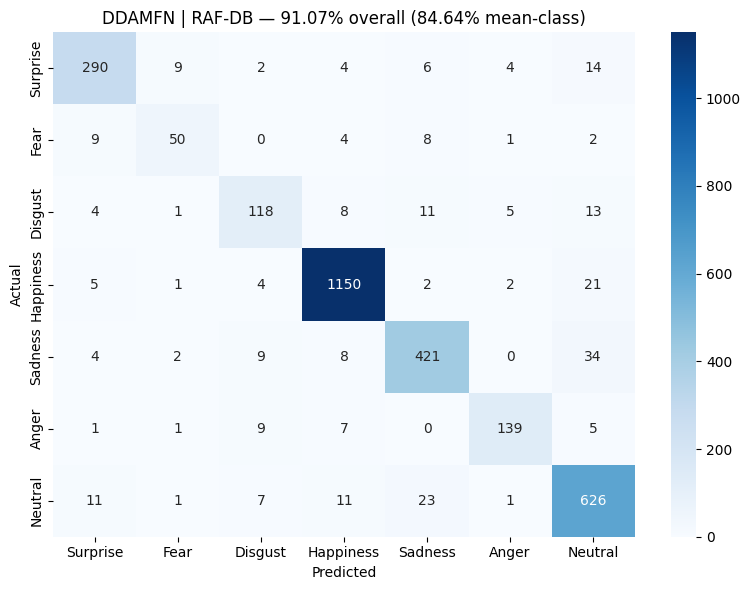

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load(BEST)['model_state_dict'])
acc, bacc, y, p = evaluate(test_loader)

print('=' * 48)
print('   DDAMFN | RAF-DB | test results')
print('=' * 48)
print(f'7-class OVERALL accuracy     : {acc*100:.2f}%')
print(f'7-class MEAN-CLASS (balanced): {bacc*100:.2f}%\n')
print(classification_report(y, p, target_names=CLASS_NAMES, digits=4))

# one consistent sentiment-scale mapping (label space 0=Surprise .. 6=Neutral)
to3 = {0: 2, 3: 2, 6: 1, 1: 0, 2: 0, 4: 0, 5: 0}   # 2=Positive{Surprise,Happiness} 1=Neutral 0=Negative{rest}
to5 = {0: 0, 1: 0, 2: 1, 5: 1, 3: 2, 4: 3, 6: 4}   # {Surprise,Fear} {Disgust,Anger} Happiness Sadness Neutral
vec = np.vectorize
acc3 = float((vec(to3.get)(y) == vec(to3.get)(p)).mean())
acc5 = float((vec(to5.get)(y) == vec(to5.get)(p)).mean())
print(f'3-scale (valence) accuracy : {acc3*100:.2f}%')
print(f'5-scale accuracy           : {acc5*100:.2f}%')

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y, p), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'DDAMFN | RAF-DB — {acc*100:.2f}% overall ({bacc*100:.2f}% mean-class)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

## 6 · Save model & results

In [6]:
results = {
    'model'         : f"DDAMFN (MFN/MS-Celeb backbone, num_head={CFG['num_head']})",
    'dataset'       : 'RAF-DB basic (12,271 train / 3,068 test)',
    'protocol'      : 'val carved from train; test evaluated once; overall + mean-class',
    'overall_acc'   : round(acc * 100, 2),
    'mean_class_acc': round(bacc * 100, 2),
    'acc_3scale'    : round(acc3 * 100, 2),
    'acc_5scale'    : round(acc5 * 100, 2),
    'epochs'        : CFG['epochs'],
    'best_val_acc'  : round(best_val * 100, 2),
}
with open('/kaggle/working/ddamfn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES, 'cfg': CFG},
           '/kaggle/working/ddamfn_rafdb_final.pth')
print(json.dumps(results, indent=2))
print('\nSaved -> ddamfn_rafdb_final.pth, ddamfn_results.json  (Output tab to download)')

{
  "model": "DDAMFN (MFN/MS-Celeb backbone, num_head=2)",
  "dataset": "RAF-DB basic (12,271 train / 3,068 test)",
  "protocol": "val carved from train; test evaluated once; overall + mean-class",
  "overall_acc": 91.07,
  "mean_class_acc": 84.64,
  "acc_3scale": 92.89,
  "acc_5scale": 92.11,
  "epochs": 40,
  "best_val_acc": 0.0
}

Saved -> ddamfn_rafdb_final.pth, ddamfn_results.json  (Output tab to download)


## 7 · Predict & explain — Grad-CAM, region focus & a natural-language explanation

Point it at a face photo. DDAMFN predicts the emotion, then the cell **explains the decision**: a
**Grad-CAM** overlay, the **class probabilities**, a **face-region focus** breakdown
(forehead / eyes / nose / mouth / jaw), and a **natural-language explanation** of the facial cues that
drove the call. (Upgraded from the original 3-model-ensemble version to the single clean DDAMFN model.)

ANALYZING : test_0001_aligned.jpg
PREDICTION: Sadness (100.0%)
------------------------------------------------------------
EXPLANATION:
The person's mouth & cheeks region reveals strong signs of Sadness.
Specifically, the inner eyebrows are pinched upward and the lips turn down. The
jaw & chin area reinforces this expression, making the emotion clearly visible.


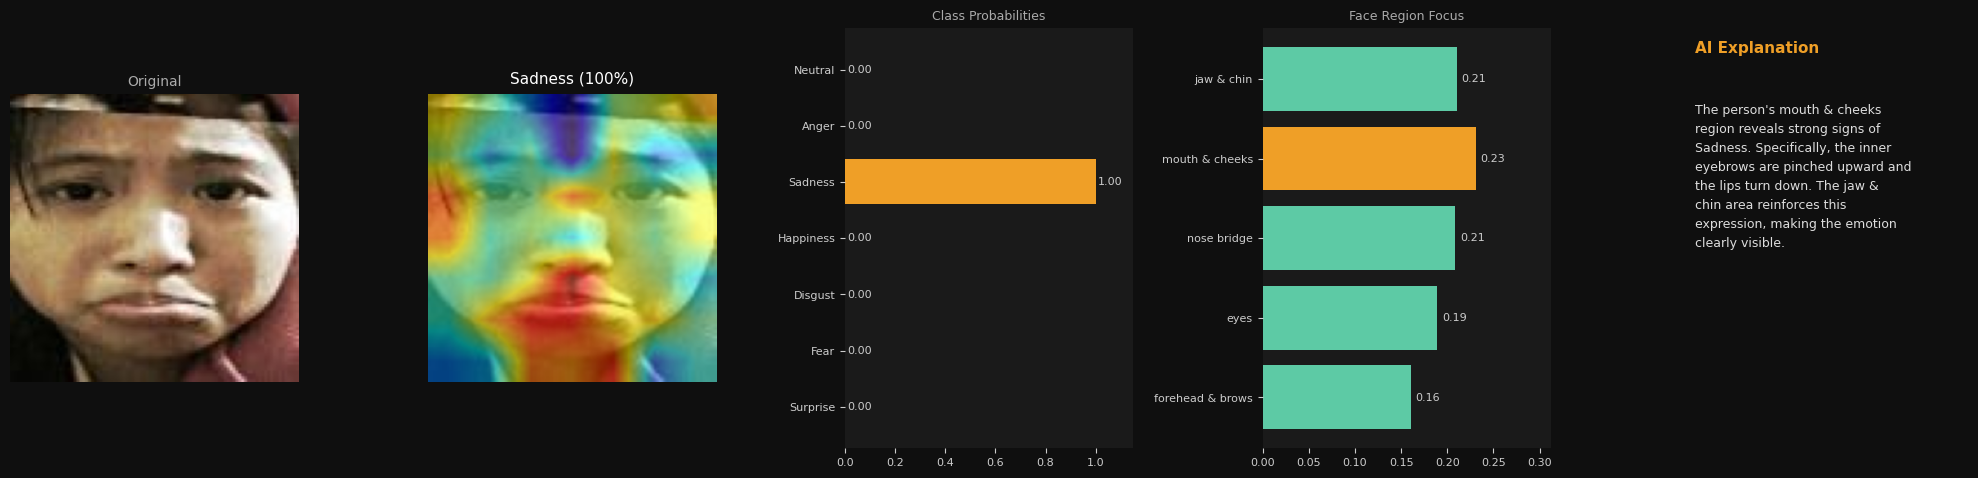

'Sadness'

In [8]:
import cv2, os, textwrap, random, torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

USE_LLM = False   # True → explanations via flan-t5-large (slower, needs transformers + ~3GB). Default = FACS template.

try:
    from facenet_pytorch import MTCNN
    _mtcnn = MTCNN(keep_all=False, post_process=False, device=DEVICE)
except Exception:
    _mtcnn = None

REGIONS = ["forehead & brows", "eyes", "nose bridge", "mouth & cheeks", "jaw & chin"]
FACS_HINTS = {
    "Happiness": ["the eyes crinkle at the corners and the mouth pulls upward into a smile",
                  "the cheeks are pushed up and the corners of the mouth are lifted"],
    "Sadness":   ["the inner eyebrows are pinched upward and the lips turn down",
                  "the eyebrows are slanted and the mouth looks heavy and downturned"],
    "Anger":     ["the eyebrows are pulled down and together into a frown",
                  "the eyes look sharp while the lips are pressed firmly together"],
    "Fear":      ["the eyes are opened very wide and the lips are stretched tightly",
                  "the eyebrows are raised and pulled together while the mouth is open"],
    "Disgust":   ["the nose is scrunched up and the upper lip is raised",
                  "the cheeks are pulled up and the nose bridge is wrinkled"],
    "Surprise":  ["the eyebrows are arched high and the jaw is dropped open",
                  "the eyes are wide and the forehead shows horizontal lines"],
    "Neutral":   ["the face is relaxed with no specific muscles tensed",
                  "the features rest in a natural and calm position"],
}

def _crop_face(img):
    if _mtcnn is not None:
        try:
            f = _mtcnn(img)
            if f is not None: return transforms.ToPILImage()(f.byte())
        except Exception: pass
    s = min(img.size)
    return img.crop(((img.width-s)//2,(img.height-s)//2,(img.width+s)//2,(img.height+s)//2))

def _gradcam(x):
    store = {}
    def _h(m,i,o): store["f"]=o; o.retain_grad()
    hh = model.features.register_forward_hook(_h)
    out, _, _ = model(x); hh.remove()
    probs = F.softmax(out,1)[0].detach().cpu().numpy(); i_cls = int(out.argmax(1))
    model.zero_grad(); out[0,i_cls].backward()
    w = store["f"].grad.mean(dim=(2,3), keepdim=True)
    cam = F.relu((w*store["f"]).sum(1,keepdim=True))
    cam = F.interpolate(cam, size=(224,224), mode="bilinear", align_corners=False)[0,0].detach().cpu().numpy()
    return (cam-cam.min())/(cam.max()-cam.min()+1e-8), probs, i_cls

def _parse_regions(cam):
    s = np.array([b.mean() for b in np.array_split(cam, 5, axis=0)]); s = s/(s.sum()+1e-8)
    return dict(zip(REGIONS, s.tolist()))

def _explain(label, regions):
    top = [k for k,_ in sorted(regions.items(), key=lambda kv:-kv[1])]
    hint = random.choice(FACS_HINTS[label])
    return (f"The person's {top[0]} region reveals strong signs of {label}. Specifically, {hint}. "
            f"The {top[1]} area reinforces this expression, making the emotion clearly visible.")

def _overlay(face224, cam):
    hm = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB).astype(np.float32)
    return np.uint8(np.clip(0.5*face224.astype(np.float32) + 0.5*hm, 0, 255))

def explain_emotion(image_path):
    model.eval()
    img = Image.open(image_path).convert("RGB"); face = _crop_face(img)
    cam, probs, i_cls = _gradcam(eval_tf(face).unsqueeze(0).to(DEVICE))
    label = CLASS_NAMES[i_cls]; conf = float(probs[i_cls]); regions = _parse_regions(cam)
    explanation = _explain(label, regions); overlay = _overlay(np.array(face.resize((224,224))), cam)
    print("="*60); print(f"ANALYZING : {os.path.basename(str(image_path))}")
    print(f"PREDICTION: {label} ({conf:.1%})"); print("-"*60)
    print("EXPLANATION:"); print(textwrap.fill(explanation, 80)); print("="*60)
    fig = plt.figure(figsize=(20,5), facecolor="#0f0f0f")
    a0=fig.add_subplot(1,5,1); a0.imshow(np.array(img)); a0.set_title("Original",color="#aaa",fontsize=10); a0.axis("off")
    a1=fig.add_subplot(1,5,2); a1.imshow(overlay); a1.set_title(f"{label} ({conf:.0%})",color="white",fontsize=11,pad=8); a1.axis("off")
    a2=fig.add_subplot(1,5,3,facecolor="#1a1a1a")
    cols=["#EF9F27" if e==label else "#5DCAA5" for e in CLASS_NAMES]
    for b,pr in zip(a2.barh(CLASS_NAMES,probs,color=cols),probs): a2.text(pr+0.01,b.get_y()+b.get_height()/2,f"{pr:.2f}",va="center",color="#ccc",fontsize=8)
    a2.set_xlim(0,1.15); a2.set_title("Class Probabilities",color="#aaa",fontsize=9); a2.tick_params(colors="#ccc",labelsize=8)
    for sp in a2.spines.values(): sp.set_visible(False)
    a3=fig.add_subplot(1,5,4,facecolor="#1a1a1a"); rn=list(regions); rs=list(regions.values())
    rcol=["#EF9F27" if v==max(rs) else "#5DCAA5" for v in rs]
    for b,v in zip(a3.barh(rn,rs,color=rcol),rs): a3.text(v+0.005,b.get_y()+b.get_height()/2,f"{v:.2f}",va="center",color="#ccc",fontsize=8)
    a3.set_xlim(0,max(rs)*1.35); a3.set_title("Face Region Focus",color="#aaa",fontsize=9); a3.tick_params(colors="#ccc",labelsize=8)
    for sp in a3.spines.values(): sp.set_visible(False)
    a4=fig.add_subplot(1,5,5,facecolor="#111"); a4.axis("off")
    a4.text(0.05,0.97,"AI Explanation",color="#EF9F27",fontweight="bold",fontsize=11,va="top")
    a4.text(0.05,0.82,textwrap.fill(explanation,32),color="#ddd",va="top",fontsize=9,linespacing=1.6)
    plt.tight_layout(pad=1.5); plt.show()
    return label

explain_emotion(IMG[test_df.iloc[0]["image"]])   # ← swap for your own photo path

## Notes
- Reported numbers are overall and mean-class accuracy on the official RAF-DB test split.
- Possible extensions: train longer (`epochs=60`), try `num_head=4`, or ensemble with a second model.
- Leaderboard context: POSTER++ 92.21%, DDAMFN 91.35%, current top ~94% (Ig3D, 2024).